In [3]:
 #Installation of required libraries 
!pip install numpy pandas matplotlib seaborn scikit-learn

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_california_housing, load_iris
import joblib

# display settings
pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')


In [14]:
# Regression dataset
housing = fetch_california_housing(as_frame=True)
df_reg = housing.frame.copy()
print("Regression dataset shape:", df_reg.shape)
df_reg.head()

# Classification dataset
iris = load_iris(as_frame=True)
df_cls = iris.frame.copy()
print("Classification dataset shape:", df_cls.shape)
df_cls.head()


Regression dataset shape: (20640, 9)
Classification dataset shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
# Regression dataset
from sklearn.datasets import fetch_california_housing, load_iris

housing = fetch_california_housing(as_frame=True)
df_reg = housing.frame.copy()
print("Regression dataset shape:", df_reg.shape)
df_reg.head()


Regression dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [16]:
# Feature matrix X and target y for regression
X_reg = df_reg.drop(columns=['MedHouseVal'])
y_reg = df_reg['MedHouseVal']

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg:", X_test_reg.shape)


X_train_reg: (16512, 8)
X_test_reg: (4128, 8)


In [17]:
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)
print("R² Score (no scaling):", r2_score(y_test_reg, y_pred_reg))

# Quick numeric comparison
res_df = pd.DataFrame({'Actual': y_test_reg.values, 'Predicted': y_pred_reg})
res_df.head()


R² Score (no scaling): 0.575787706032451


,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657


In [18]:
pipeline_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline_reg.fit(X_train_reg, y_train_reg)
y_pred_pipe = pipeline_reg.predict(X_test_reg)
print("Pipeline R² Score:", r2_score(y_test_reg, y_pred_pipe))


Pipeline R² Score: 0.5757877060324508


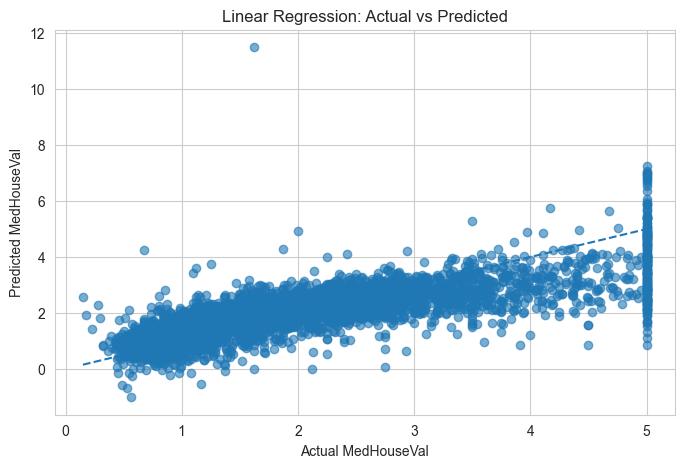

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], linestyle='--')
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


In [20]:
# Save pipeline (preferred to include scaler)
joblib.dump(pipeline_reg, 'pipeline_reg_model.pkl')

# Load back
loaded_pipeline = joblib.load('pipeline_reg_model.pkl')
print("Loaded pipeline R²:", r2_score(y_test_reg, loaded_pipeline.predict(X_test_reg)))


Loaded pipeline R²: 0.5757877060324508


In [21]:
# For iris dataset
X_cls = df_cls.drop(columns=['target'])
y_cls = df_cls['target']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42
)

print("X_train_cls:", X_train_cls.shape)
print("X_test_cls:", X_test_cls.shape)


X_train_cls: (112, 4)
X_test_cls: (38, 4)


In [22]:
from sklearn.datasets import fetch_california_housing, load_iris

# Regression dataset
housing = fetch_california_housing(as_frame=True)
df_reg = housing.frame.copy()
print("Regression dataset shape:", df_reg.shape)

# Classification dataset
iris = load_iris(as_frame=True)
df_cls = iris.frame.copy()
print("Classification dataset shape:", df_cls.shape)

df_cls.head()


Regression dataset shape: (20640, 9)
Classification dataset shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = load_iris(as_frame=True)
df_cls = iris.frame.copy()

# Split data
X_cls = df_cls.drop(columns=['target'])
y_cls = df_cls['target']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42
)


In [4]:
pipeline_cls = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=200))
])

pipeline_cls.fit(X_train_cls, y_train_cls)
y_pred_cls = pipeline_cls.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_cls, y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_cls))


Accuracy: 1.0

Confusion Matrix:
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

